C:\Users\moria\AppData\Local\Temp\ipykernel_24988\2212165326.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


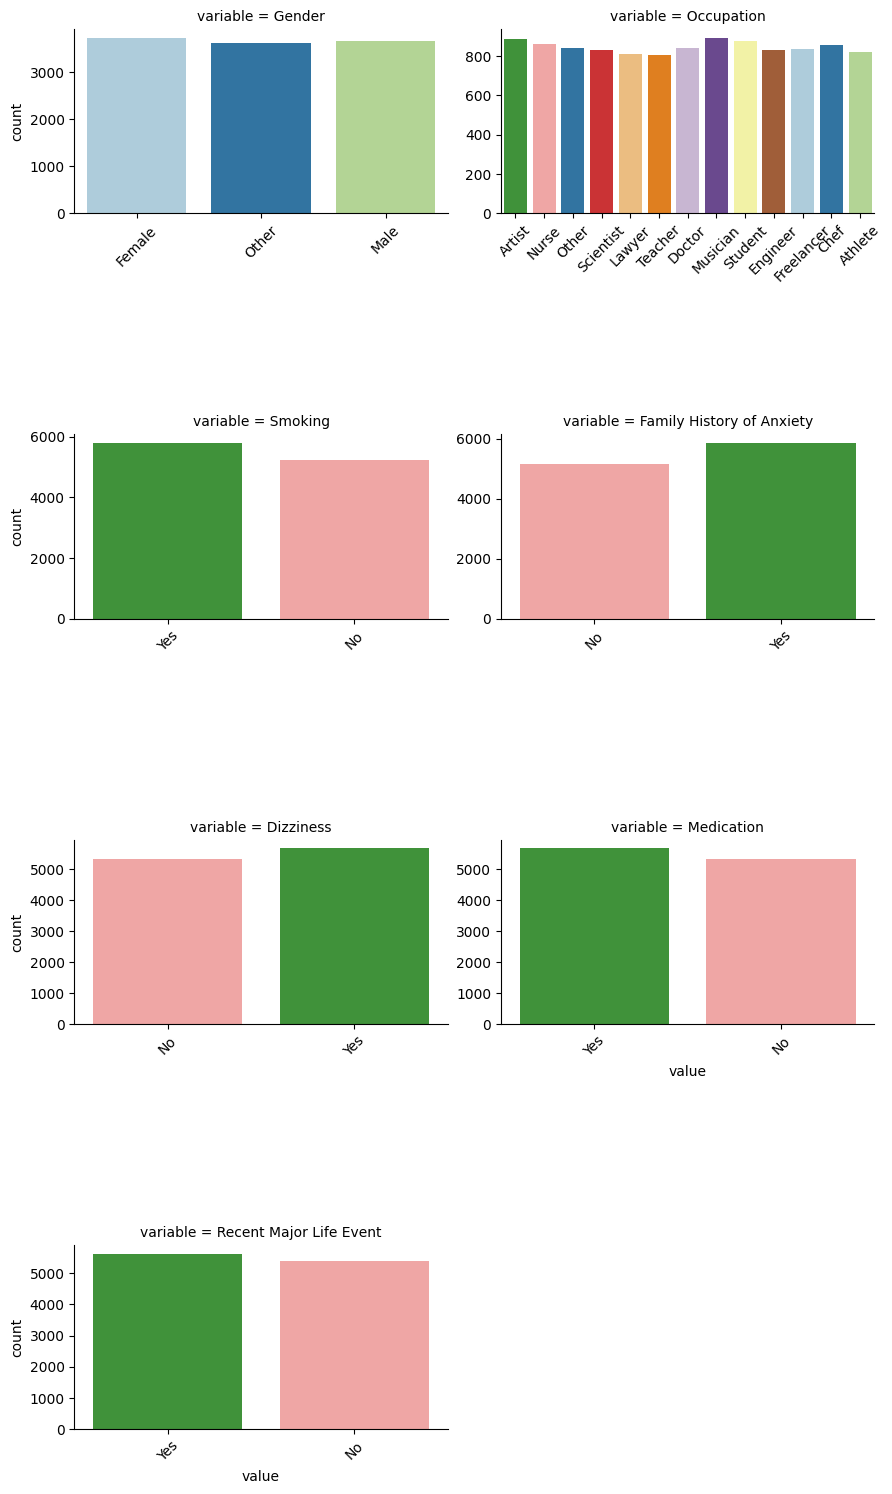

None


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# -----------------------------
# Logger Configuration
# -----------------------------

logger = logging.getLogger(__name__)


# -----------------------------
# Null Check Function
# -----------------------------
def is_null(df):
    """
    Check whether the dataframe contains any null values.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    Returns
    -------
    bool
        True if null values exist, otherwise False.
    """
    try:
        null_count = df.isnull().sum(axis=0)
        has_nulls = null_count.sum() != 0
        logger.info(f"Null check completed. Contains nulls: {has_nulls}")
        return has_nulls

    except Exception as e:
        logger.error(f"Error in is_null: {e}")
        raise


# -----------------------------
# Outlier Detection
# -----------------------------
def get_outliers_report(df):
    """
    Generate a detailed outlier report using the IQR method.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    Returns
    -------
    outliers_detailed : pd.DataFrame
        Rows identified as outliers with reason.
    long_df : pd.DataFrame
        Long-format dataframe including bounds.
    """
    try:
        num_df = df.select_dtypes(include=['number'])

        if num_df.empty:
            raise ValueError("No numeric columns found for outlier detection")

        # Compute IQR bounds
        q1 = num_df.quantile(0.25)
        q3 = num_df.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Convert to long format
        long_df = num_df.reset_index().melt(
            id_vars='index',
            var_name='column',
            value_name='value'
        )

        # Attach bounds
        long_df['lower'] = long_df['column'].map(lower_bound)
        long_df['upper'] = long_df['column'].map(upper_bound)

        # Identify outliers
        outliers_detailed = long_df[
            (long_df['value'] < long_df['lower']) |
            (long_df['value'] > long_df['upper'])
        ].copy()

        outliers_detailed['reason'] = np.where(
            outliers_detailed['value'] > outliers_detailed['upper'],
            'Too High',
            'Too Low'
        )

        logger.info(f"Outlier detection completed. Found {len(outliers_detailed)} outliers.")
        return outliers_detailed, long_df

    except Exception as e:
        logger.error(f"Error in get_outliers_report: {e}")
        raise


# -----------------------------
# Outlier Plotting
# -----------------------------
def plot_outliers(df):
    """
    Plot boxplots for raw and cleaned data after removing outliers.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    Returns
    -------
    pd.DataFrame
        Cleaned dataframe (wide format).
    """
    try:
        outliers_df, long_df_raw = get_outliers_report(df)

        # Remove outliers from long-format table
        long_df_clean = long_df_raw.drop(outliers_df.index)

        # Helper function for plotting
        def draw(data, title):
            g = sns.FacetGrid(
                data,
                col="column",
                col_wrap=4,
                sharey=False,
                sharex=False,
                height=3,
                aspect=1.2
            )
            g.map(sns.boxplot, "value", color="skyblue")
            g.set_titles("{col_name}")
            g.set_xticklabels(rotation=45)
            g.fig.suptitle(title, y=1.05, fontsize=16)
            plt.tight_layout()
            plt.show()

        # Draw plots
        draw(long_df_raw, 'Raw Data (With Outliers)')
        draw(long_df_clean, 'Clean Data (After Removing Outliers)')

        # Return cleaned wide-format dataframe
        idx_to_drop = outliers_df['index']
        logger.info(f"Removing {len(idx_to_drop)} rows due to outliers.")
        return df.drop(index=idx_to_drop)

    except Exception as e:
        logger.error(f"Error in plot_outliers: {e}")
        raise


# -----------------------------
# Frequency Plot for Categorical Variables
# -----------------------------
def frequency(df):
    """
    Plot frequency counts for all categorical variables.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    Returns
    -------
    None
    """
    try:
        cat_df = df.select_dtypes(include=['object', 'category'])

        if cat_df.empty:
            raise ValueError("No categorical columns found for frequency plotting")

        df_melted = cat_df.melt()

        g = sns.catplot(
            data=df_melted,
            kind="count",
            x="value",
            col="variable",
            col_wrap=2,
            sharex=False,
            sharey=False,
            palette="Paired"
        )

        g.set_xticklabels(rotation=45)
        g.fig.subplots_adjust(hspace=1.2, bottom=0.2, top=0.9, left=0.1, right=0.9)
        plt.show()

        logger.info("Frequency plots generated successfully.")

    except Exception as e:
        logger.error(f"Error in frequency: {e}")
        raise

data = pd.read_csv(r"C:\Users\moria\OneDrive - Bar-Ilan University - Students\לימודים\שנה ב תשפו 2025-2026\סמסטר א\פייתון\Python Project\enhanced_anxiety_dataset.csv")
print(frequency(data))
